# Setup

In [1]:
%load_ext autoreload
%autoreload 2

# %matplotlib widget

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tpvalidator.workspace as workspace
import tpvalidator.analysis.snn as snn
import mplhep as hep

from rich import print


# Data

In [3]:
import tpvalidator.datacatalogue as dctl

dataset_name = 'radbkg'
datasets = dctl.load('data/vd/1x8x14/3sig', dataset_name)
rad_ws=datasets[dataset_name]


Dataset 'radbkg': 10 events

{
    'backtracker': {'TPAlgTPCSimpleThreshold': {'offset_U': 8, 'offset_V': 1, 'offset_X': -7}},
    'geo': {'detector': 'dunevd10kt_3view_30deg_v5_refactored_1x8x14ref'},
    'mctruth_blockid_map': [
        [28, 'Rn222ChainFromPo218GenInUpperMesh1x8x14'],
        [27, 'Rn220ChainFromPb212GenInUpperMesh1x8x14'],
        [26, 'Kr85GenInLAr'],
        [25, 'Rn222ChainFromBi210GenInUpperMesh1x8x14'],
        [24, 'U238ChainGenInAnode'],
        [23, 'K40GenInCathode'],
        [22, 'K42From42ArGenInUpperMesh1x8x14'],
        [21, 'Th232ChainGenInCathode'],
        [20, 'CavernNGammasAtLAr1x8x14'],
        [19, 'Rn222ChainRn222GenInLAr'],
        [18, 'U238ChainGenInCathode'],
        [17, 'K40GenInAnode'],
        [16, 'Rn220ChainPb212GenInLAr'],
        [15, 'foamGammasAtLAr1x8x14'],
        [14, 'Rn222ChainFromPb214GenInUpperMesh1x8x14'],
        [13, 'K42From42ArGenInLAr'],
        [12, 'Rn222ChainGenInPDS'],
        [11, 'Ar42GenInLAr'],
        [10, 'CavernwallGammasAtLAr1x8x14'],
        [9, 'Rn222ChainPb210GenInLAr'],
        [8, 'Ar39GenInLAr'],
        [7, 'Rn222ChainPb214GenInLAr'],
        [6, 'Rn222ChainFromPb210GenInUpperMesh1x8x14'],
        [5, 'Rn222ChainPo218GenInLAr'],
        [4, 'CavernwallNeutronsAtLAr1x8x14'],
        [3, 'Rn222ChainFromBi214GenInUpperMesh1x8x14'],
        [2, 'CryostatNGammasAtLAr1x8x14'],
        [1, 'Th232ChainGenInAnode'],
        [0, 'Rn222ChainBi214GenInLAr']
    ],
    'tpg': {
        'tpmakerTPCSimpleThreshold::TriggerPrimitiveMaker': {
            'threshold_tpg_plane0': 27,
            'threshold_tpg_plane1': 27,
            'threshold_tpg_plane2': 27,
            'tool': 'TPAlgTPCSimpleThreshold'
        }
    }
}

In [4]:
from tpvalidator.viz.tps import TrgPrimitivesPlotter

tpp = TrgPrimitivesPlotter(rad_ws)

In [ ]:
from tpvalidator.analysis.snn import TPSignalNoiseSelector

tpsel = TPSignalNoiseSelector(rad_ws.tps)

In [ ]:
import hist

def make_int_axis(df, col_name:str, **kwargs):

    if df[col_name].dtype.kind not in ("i", "u"):
        raise TypeError(f"Column {col_name} is not of type integer")

    values = df[col_name].values
    lo, hi = np.min(values), np.max(values)
    return hist.axis.Integer(lo, hi+1, name=col_name, **kwargs)

def make_intcat_axis(df, col_name:str, **kwargs):

    if df[col_name].dtype.kind not in ("i", "u"):
        raise TypeError(f"Column {col_name} is not of type integer")

    return hist.axis.IntCategory(df[col_name].unique(), name=col_name, **kwargs)

_df=rad_ws.tps

rop_axis = make_intcat_axis(_df, 'readout_plane_id', label='Readout Plane')
bt_sig_axis = make_intcat_axis(_df, 'bt_is_signal', label='Noise/Signal')

min_adc_peak = 27
max_adc_peak = 62
n_bins = 7
adc_peak_axis = hist.axis.Regular(n_bins, min_adc_peak, max_adc_peak, name='adc_peak')




In [89]:
_df.columns

Index(['event', 'run', 'subrun', 'version', 'flag', 'detid', 'channel',
       'samples_over_threshold', 'time_start', 'samples_to_peak',
       'adc_integral', 'adc_peak', 'readout_plane_id', 'readout_view',
       'TPCSetID', 'bt_primary_track_id', 'bt_primary_track_numelectron_frac',
       'bt_primary_track_energy_frac', 'bt_edep', 'bt_numelectrons', 'bt_x',
       'bt_y', 'bt_z', 'bt_primary_x', 'bt_primary_y', 'bt_primary_z',
       'bt_truth_block_id', 'bt_generator_name', 'event_uid', 'time_peak',
       'sample_start', 'sample_peak', 'bt_is_signal'],
      dtype='str')

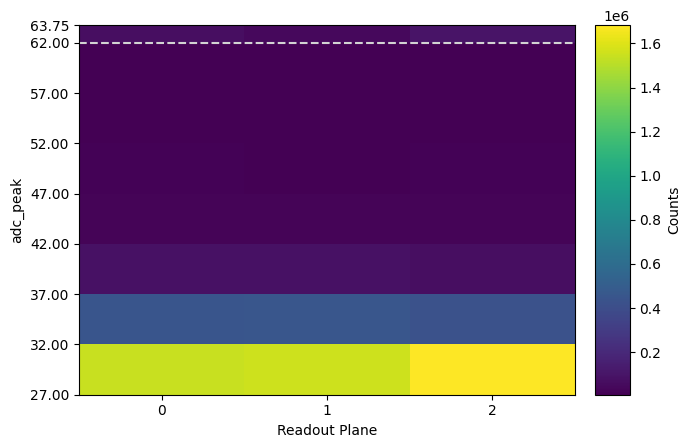

In [104]:
h = hist.Hist(rop_axis, adc_peak_axis)

kwa={
    'readout_plane_id': _df['readout_plane_id'],
    'adc_peak': _df['adc_peak'],
}
h.fill(**kwa)

artists = hep.hist2dplot(h, flow='show')
artists.cbar.set_label("Counts")



[      0. 1682983.  426140.   68624.   21795.   15066.   12408.   10375.
   93295.]

[StairsArtists(stairs=<matplotlib.patches.StepPatch object at 0x120323ed0>, errorbar=<ErrorbarContainer object of 3 artists>, legend_artist=<ErrorbarContainer object of 3 artists>)]

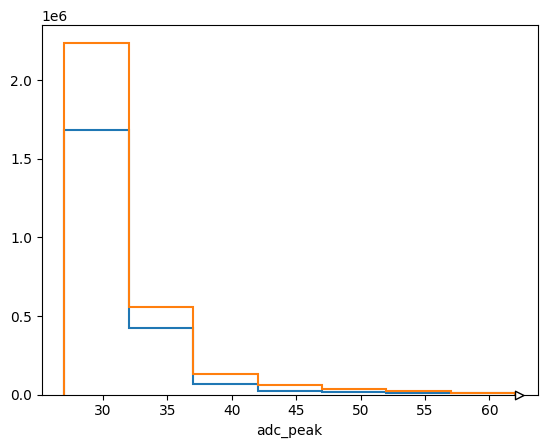

In [108]:
from tpvalidator.analysis.histograms import make_cumulative

h_coll = h[2,:]

print(h_coll.values(flow=True)      )
hep.histplot(h_coll)

h_coll_cum = make_cumulative(h_coll, direction='right')
hep.histplot(h_coll_cum)


26

+-----------------------------------------------------------------+
-1 0       |                                                                 |
 0 2199819 |============================================================     |
 1 2185897 |============================================================     |
 2 2330686 |================================================================ |
 3 0       |                                                                 |
           +-----------------------------------------------------------------+

30

+------------------------------------------------------------------+
-1 0      |                                                                  |
 0 881677 |================================================================= |
 1 855305 |===============================================================   |
 2 878064 |================================================================= |
 3 0      |                                                                  |
          +------------------------------------------------------------------+

34

...

+------------------------------------------------------------------+
-1 0      |                                                                  |
 0 157645 |=========================================================         |
 1 125304 |=============================================                     |
 2 181359 |================================================================= |
 3 0      |                                                                  |
          +------------------------------------------------------------------+

42

+------------------------------------------------------------------+
-1 0      |                                                                  |
 0 117564 |====================================================              |
 1 85635  |======================================                            |
 2 147275 |================================================================= |
 3 0      |                                                                  |
          +------------------------------------------------------------------+

46

+------------------------------------------------------------------+
-1 0      |                                                                  |
 0 100582 |==================================================                |
 1 69872  |===================================                               |
 2 131144 |================================================================= |
 3 0      |                                                                  |
          +------------------------------------------------------------------+

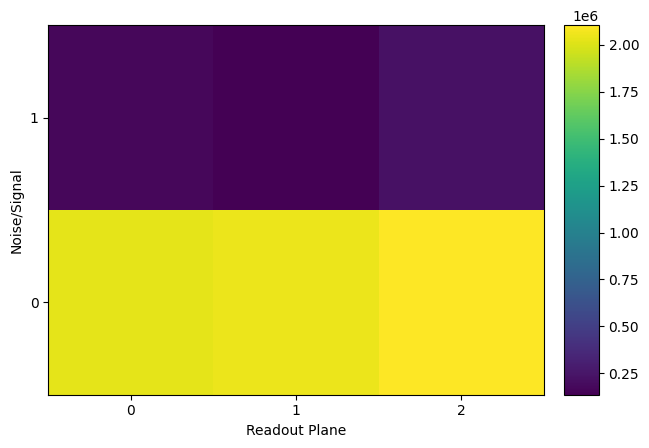

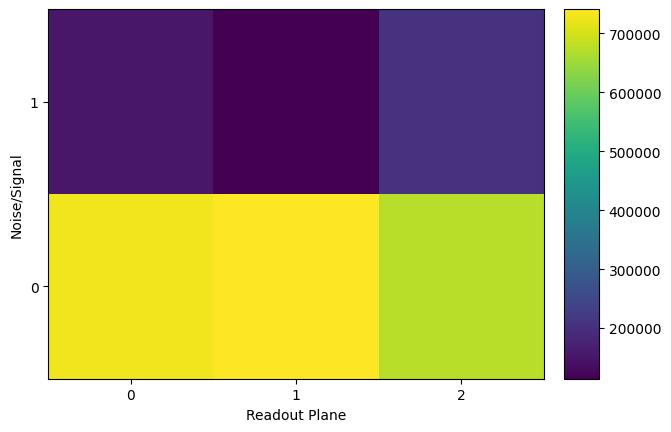

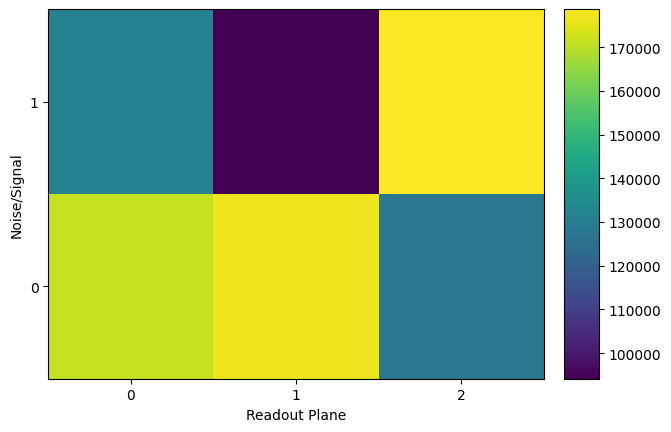

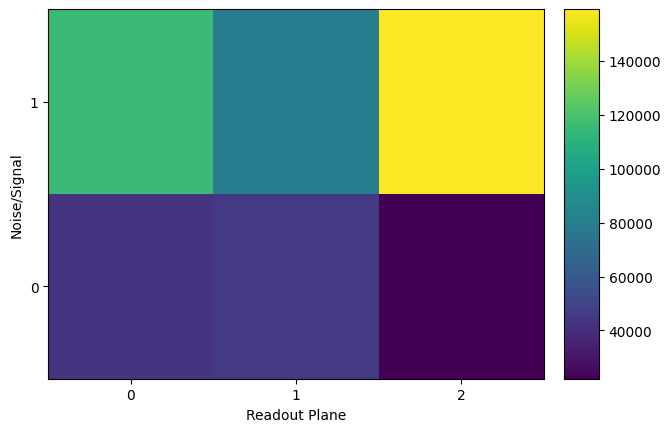

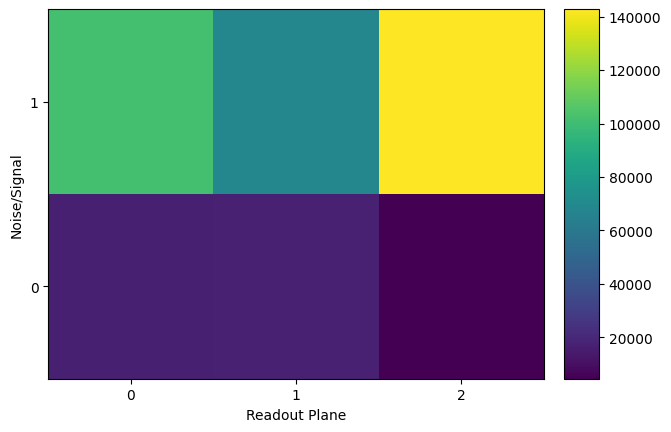

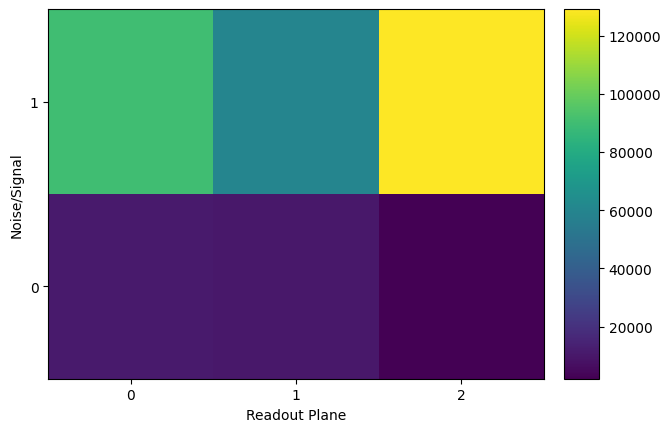

In [81]:






hists = {}
for adc_thres in range(26, 50, 4):
    _df_cut=_df.query(f'adc_peak > {adc_thres}')

    h = hist.Hist(rop_axis, bt_sig_axis)

    h.fill(readout_plane_id=_df_cut['readout_plane_id'], bt_is_signal=_df_cut['bt_is_signal'])

    # display(h)
    hists[adc_thres] = h

for n,h in hists.items():
    fig, ax = plt.subplots()
    hep.hist2dplot(h, ax=ax)

for n,h in hists.items():
    print(n)
    print(h[:, sum])



In [14]:
tpsel.sig_by_view[0]

event    run  subrun  version  flag  detid  channel  \
entry subentry                                                        
0     0             1  99001       0        2     0      3    95922   
      1             1  99001       0        2     0      3    95923   
      3             1  99001       0        2     0      3    95944   
      9             1  99001       0        2     0      3    95949   
      15            1  99001       0        2     0      3    95954   
...               ...    ...     ...      ...   ...    ...      ...   
9     668022        5  99001       1        2     0      3      257   
      668023        5  99001       1        2     0      3      258   
      668027        5  99001       1        2     0      3      264   
      668028        5  99001       1        2     0      3      264   
      668029        5  99001       1        2     0      3      267   

                samples_over_threshold  time_start  samples_to_peak  ...  \
entry subentry                                                       ...   
0     0                              2       50144                1  ...   
      1                              6       50016                3  ...   
      3                              6      162464                3  ...   
      9                              2      157408                0  ...   
      15                             4       36064                3  ...   
...                                ...         ...              ...  ...   
9     668022                         6      250336                2  ...   
      668023                         6      250336                2  ...   
      668027                         4       39872                2  ...   
      668028                         6      202432                3  ...   
      668029                         1      236480                0  ...   

                bt_primary_x  bt_primary_y  bt_primary_z  bt_truth_block_id  \
entry subentry                                                                
0     0           198.401642    513.960205   1969.147583                  8   
      1           198.402817    513.966858   1969.153076                  8   
      3            35.387203    512.494141   2003.964478                  8   
      9           313.666901    540.348145   1963.247925                 10   
      15         -177.105255    545.124084   1962.454102                  8   
...                      ...           ...           ...                ...   
9     668022      128.925674   -526.858521    139.013382                  8   
      668023      128.925125   -526.856445    139.012863                  8   
      668027      321.325348   -515.180786    128.937729                 10   
      668028      324.570862   -513.353638    125.073624                 10   
      668029      261.730408   -523.645203    147.610962                 10   

                          bt_generator_name  event_uid  time_peak  \
entry subentry                                                      
0     0                        Ar39GenInLAr  216752193      50176   
      1                        Ar39GenInLAr  216752193      50112   
      3                        Ar39GenInLAr  216752193     162560   
      9         CavernwallGammasAtLAr1x8x14  216752193     157408   
      15                       Ar39GenInLAr  216752193      36160   
...                                     ...        ...        ...   
9     668022                   Ar39GenInLAr  216752297     250400   
      668023                   Ar39GenInLAr  216752297     250400   
      668027    CavernwallGammasAtLAr1x8x14  216752297      39936   
      668028    CavernwallGammasAtLAr1x8x14  216752297     202528   
      668029    CavernwallGammasAtLAr1x8x14  216752297     236480   

                sample_start  sample_peak  bt_is_signal  
entry subentry                                           
0     0                 1567         1568             1  
   

In [9]:
tpp._make_groups(tpp.df, 'signal_noise')

{0:                 event    run  subrun  version  flag  detid  channel  \
 entry subentry                                                        
 0     2             1  99001       0        2     0      3    95941   
       4             1  99001       0        2     0      3    95947   
       5             1  99001       0        2     0      3    95947   
       6             1  99001       0        2     0      3    95948   
       7             1  99001       0        2     0      3    95948   
 ...               ...    ...     ...      ...   ...    ...      ...   
 9     672146        5  99001       1        2     0      3      863   
       672147        5  99001       1        2     0      3      863   
       672148        5  99001       1        2     0      3      863   
       672149        5  99001       1        2     0      3      863   
       672151        5  99001       1        2     0      3      863   
 
                 samples_over_threshold  time_start  sample

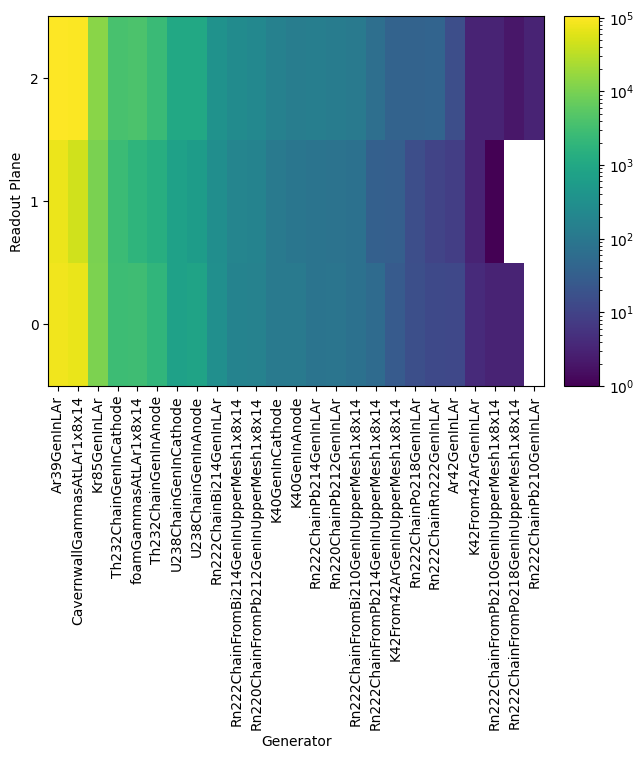

In [67]:

from matplotlib.colors import LogNorm

fig, ax = plt.subplots()
h = tpp.make_generator_counts_hist('bt_is_signal == 1')
norm = LogNorm(vmin=1, vmax=h.values().max())

hep.hist2dplot(h, ax=ax,  norm=norm)
ax.tick_params(axis='x', rotation=90)


In [ ]:
h[sum, :]

Hist(Regular(3, 0, 3, name='rop', label='Readout Plane'), storage=Double()) # Sum: 536876.0

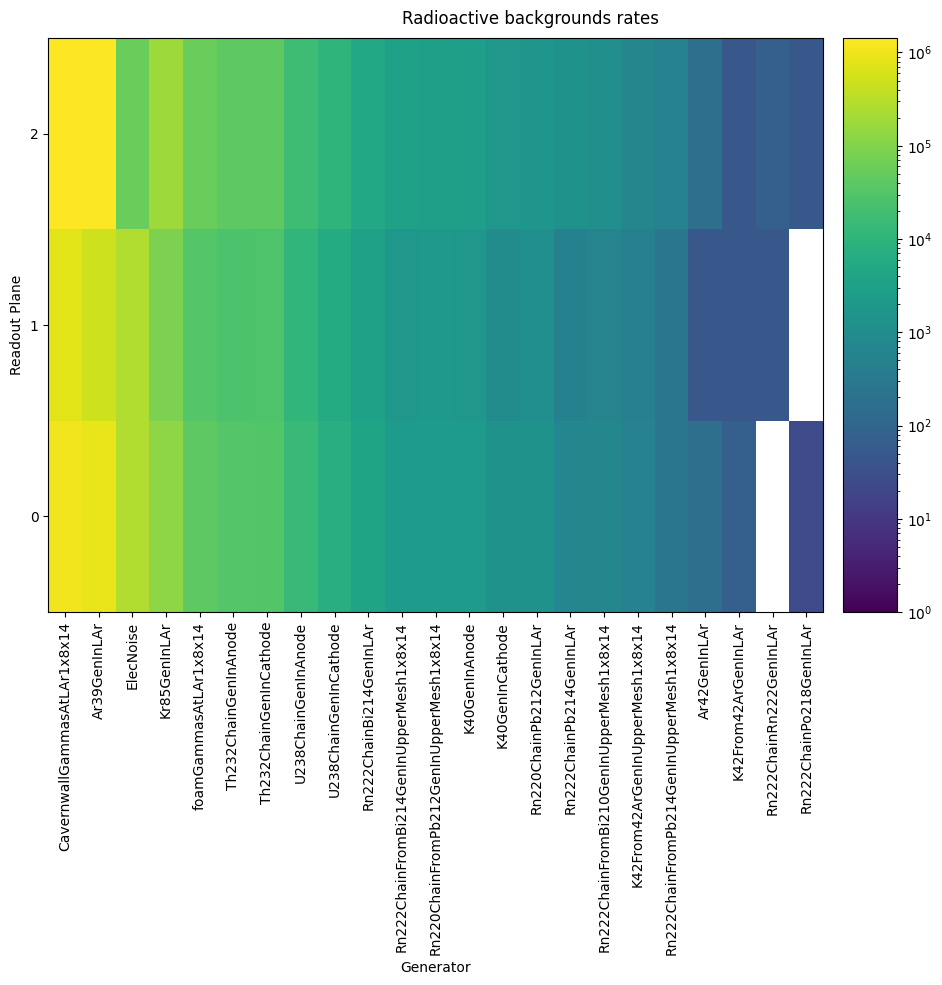

In [69]:
fig = tpp.plot_generator_activity(cut='adc_peak>45', norm='rate')

In [70]:
print(tpp.make_generator_rates_table( "adc_peak >45 & readout_plane_id==0"))
print(tpp.make_generator_rates_table( "adc_peak >45 & readout_plane_id==1"))
print(tpp.make_generator_rates_table( "adc_peak >45 & readout_plane_id==2"))

                Backgrounds generators by activity                
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━┳━━━━━━━━━━━━┓
┃ generator name                          ┃ entries ┃ rate [Hz]  ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━╇━━━━━━━━━━━━┩
│ CavernwallGammasAtLAr1x8x14             │ 44010   │ 1035529.41 │
│ Ar39GenInLAr                            │ 36911   │ 868494.12  │
│ ElecNoise                               │ 11457   │ 269576.47  │
│ Kr85GenInLAr                            │ 5564    │ 130917.65  │
│ foamGammasAtLAr1x8x14                   │ 1817    │ 42752.94   │
│ Th232ChainGenInAnode                    │ 1395    │ 32823.53   │
│ Th232ChainGenInCathode                  │ 1278    │ 30070.59   │
│ U238ChainGenInAnode                     │ 582     │ 13694.12   │
│ U238ChainGenInCathode                   │ 307     │ 7223.53    │
│ Rn222ChainBi214GenInLAr                 │ 164     │ 3858.82    │
│ K40GenInAnode                           │ 97      │ 2282.35    │
│ Rn222ChainFromBi214GenInUpperMesh1x8x14 │ 95      │ 2235.29    │
│ Rn220ChainFromPb212GenInUpperMesh1x8x14 │ 94      │ 2211.76    │
│ K40GenInCathode                         │ 56      │ 1317.65    │
│ Rn220ChainPb212GenInLAr                 │ 56      │ 1317.65    │
│ Rn222ChainFromBi210GenInUpperMesh1x8x14 │ 30      │ 705.88     │
│ Rn222ChainPb214GenInLAr                 │ 29      │ 682.35     │
│ K42From42ArGenInUpperMesh1x8x14         │ 21      │ 494.12     │
│ Rn222ChainFromPb214GenInUpperMesh1x8x14 │ 11      │ 258.82     │
│ Ar42GenInLAr                            │ 7       │ 164.71     │
│ K42From42ArGenInLAr                     │ 3       │ 70.59      │
│ Rn222ChainPo218GenInLAr                 │ 1       │ 23.53      │
└─────────────────────────────────────────┴─────────┴────────────┘

               Backgrounds generators by activity                
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━┳━━━━━━━━━━━┓
┃ generator name                          ┃ entries ┃ rate [Hz] ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━╇━━━━━━━━━━━┩
│ CavernwallGammasAtLAr1x8x14             │ 32375   │ 761764.71 │
│ Ar39GenInLAr                            │ 20838   │ 490305.88 │
│ ElecNoise                               │ 11196   │ 263435.29 │
│ Kr85GenInLAr                            │ 3631    │ 85435.29  │
│ foamGammasAtLAr1x8x14                   │ 1367    │ 32164.71  │
│ Th232ChainGenInCathode                  │ 1141    │ 26847.06  │
│ Th232ChainGenInAnode                    │ 1128    │ 26541.18  │
│ U238ChainGenInAnode                     │ 461     │ 10847.06  │
│ U238ChainGenInCathode                   │ 241     │ 5670.59   │
│ Rn222ChainBi214GenInLAr                 │ 134     │ 3152.94   │
│ Rn220ChainFromPb212GenInUpperMesh1x8x14 │ 85      │ 2000.00   │
│ K40GenInAnode                           │ 83      │ 1952.94   │
│ Rn222ChainFromBi214GenInUpperMesh1x8x14 │ 81      │ 1905.88   │
│ Rn220ChainPb212GenInLAr                 │ 46      │ 1082.35   │
│ K40GenInCathode                         │ 39      │ 917.65    │
│ Rn222ChainFromBi210GenInUpperMesh1x8x14 │ 25      │ 588.24    │
│ Rn222ChainPb214GenInLAr                 │ 20      │ 470.59    │
│ K42From42ArGenInUpperMesh1x8x14         │ 19      │ 447.06    │
│ Rn222ChainFromPb214GenInUpperMesh1x8x14 │ 11      │ 258.82    │
│ Ar42GenInLAr                            │ 2       │ 47.06     │
│ K42From42ArGenInLAr                     │ 2       │ 47.06     │
│ Rn222ChainRn222GenInLAr                 │ 2       │ 47.06     │
└─────────────────────────────────────────┴─────────┴───────────┘

                Backgrounds generators by activity                
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━┳━━━━━━━━━━━━┓
┃ generator name                          ┃ entries ┃ rate [Hz]  ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━╇━━━━━━━━━━━━┩
│ CavernwallGammasAtLAr1x8x14             │ 60735   │ 1429058.82 │
│ Ar39GenInLAr                            │ 55715   │ 1310941.18 │
│ Kr85GenInLAr                            │ 7752    │ 182400.00  │
│ foamGammasAtLAr1x8x14                   │ 2448    │ 57600.00   │
│ ElecNoise                               │ 2417    │ 56870.59   │
│ Th232ChainGenInCathode                  │ 1822    │ 42870.59   │
│ Th232ChainGenInAnode                    │ 1773    │ 41717.65   │
│ U238ChainGenInAnode                     │ 726     │ 17082.35   │
│ U238ChainGenInCathode                   │ 429     │ 10094.12   │
│ Rn222ChainBi214GenInLAr                 │ 203     │ 4776.47    │
│ Rn222ChainFromBi214GenInUpperMesh1x8x14 │ 131     │ 3082.35    │
│ Rn220ChainFromPb212GenInUpperMesh1x8x14 │ 120     │ 2823.53    │
│ K40GenInAnode                           │ 112     │ 2635.29    │
│ K40GenInCathode                         │ 83      │ 1952.94    │
│ Rn220ChainPb212GenInLAr                 │ 72      │ 1694.12    │
│ Rn222ChainPb214GenInLAr                 │ 59      │ 1388.24    │
│ Rn222ChainFromBi210GenInUpperMesh1x8x14 │ 49      │ 1152.94    │
│ K42From42ArGenInUpperMesh1x8x14         │ 30      │ 705.88     │
│ Rn222ChainFromPb214GenInUpperMesh1x8x14 │ 21      │ 494.12     │
│ Ar42GenInLAr                            │ 7       │ 164.71     │
│ Rn222ChainRn222GenInLAr                 │ 3       │ 70.59      │
│ K42From42ArGenInLAr                     │ 2       │ 47.06      │
│ Rn222ChainPo218GenInLAr                 │ 2       │ 47.06      │
└─────────────────────────────────────────┴─────────┴────────────┘

In [ ]:
coll_tps = ws.tps.query('readout_view == 2 & sample_start >100 & sample_start < 8100 & bt_is_signal == 1 ')
coll_tps.extra_info.update({'readout_window': 8000})


NameError: name 'ws' is not defined

In [ ]:
tps_by_gen = sorted([(n,df) for n,df in coll_tps.groupby('bt_generator_name')], reverse=True, key=lambda x: len(x[1]))


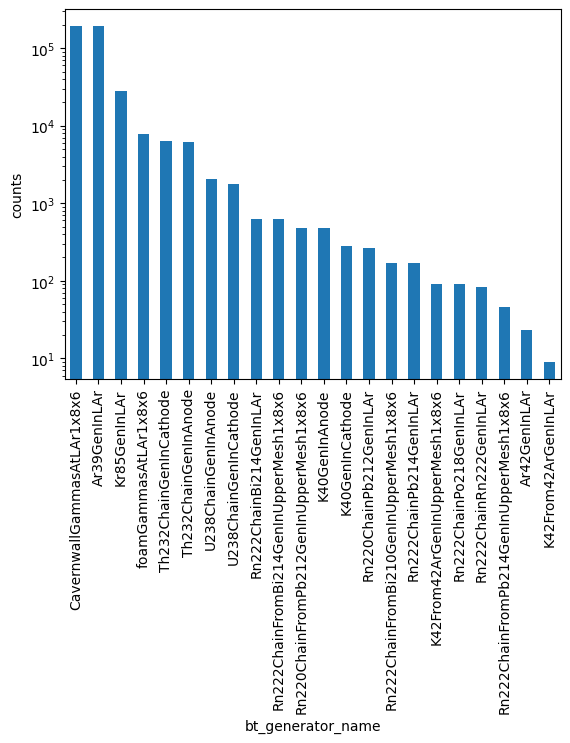

In [ ]:
counts = coll_tps.bt_generator_name.value_counts()
ax = counts.plot.bar()
ax.set_ylabel('counts')
ax.set_yscale('log')